PCA理解用のコード、データの生成

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import linregress # 線形回帰用

num_points = 2000

生成された2次元データの最初の5点:
[[ 1.15724539  2.05446855]
 [ 0.52302791 -0.62041057]
 [ 1.52477207 -0.77271672]
 [ 1.14843782  0.51515449]
 [ 0.75708284  0.58607349]]


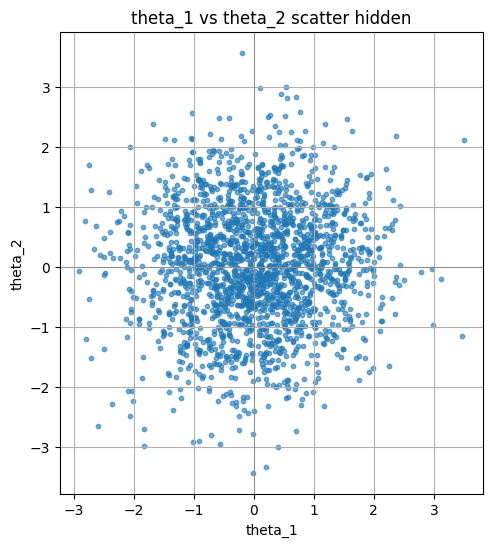

In [ ]:
# データ点数
# 平均と標準偏差の設定
mean = 0
std_dev = 1

# θ1とθ2を独立な正規分布から生成
theta1 = np.random.normal(mean, std_dev, num_points)
theta2 = np.random.normal(mean, std_dev, num_points)

# データ点を結合
# 各行が1つのデータ点 (theta1, theta2) を表す
hidden_data_2d = np.column_stack((theta1, theta2))

print("生成された2次元データの最初の5点:")
print(hidden_data_2d[:5])

# 散布図で可視化 (オプション)
plt.figure(figsize=(6, 6))
plt.scatter(theta1, theta2, alpha=0.6, s=10)
plt.title(r'theta_1 vs theta_2 scatter hidden')
plt.xlabel(r'theta_1')
plt.ylabel(r'theta_2')
plt.grid(True)
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

3次元の軸に投影して、任意の2軸間でのプロット


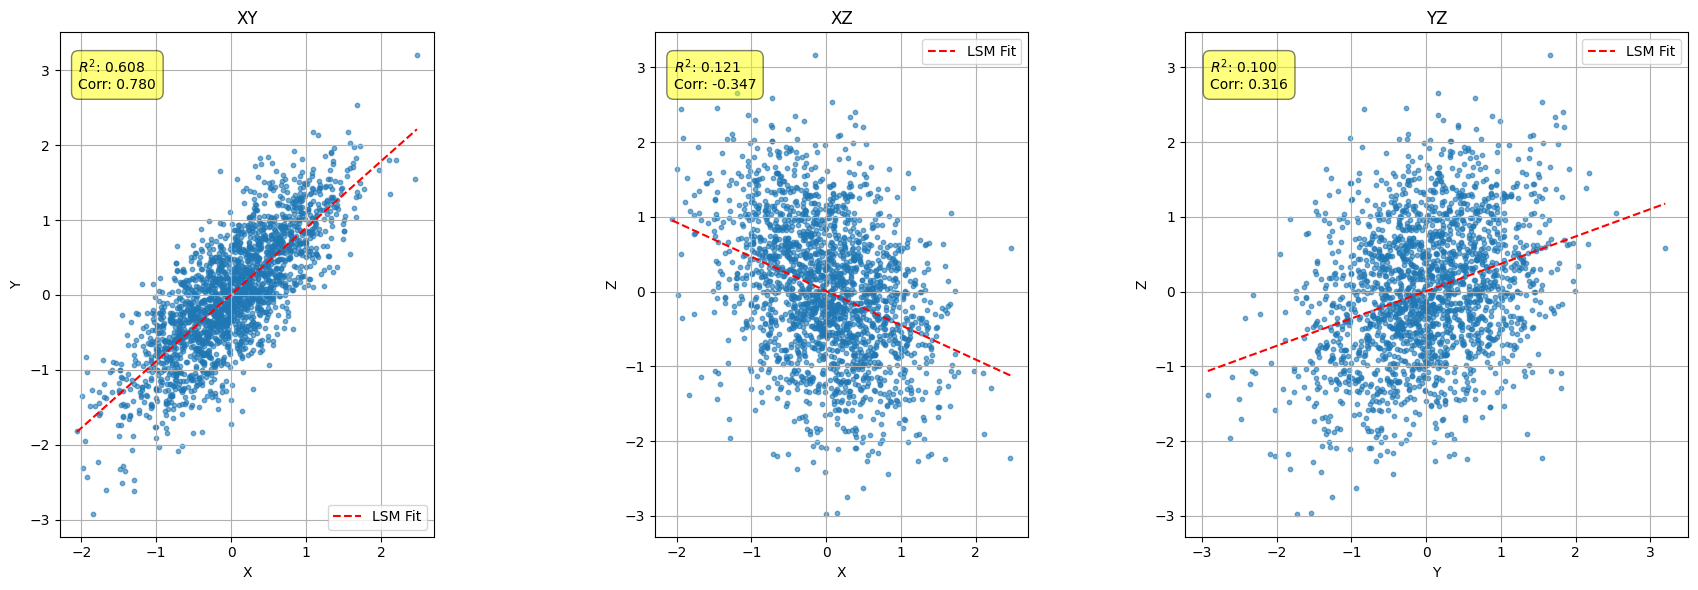

In [ ]:


# --- 前のステップで生成・回転したデータを使用 ---
# 例として、前のステップのデータ生成と回転コードを再度実行します
alpha = np.pi / 3
beta = np.pi / 4
data_3d_initial = np.column_stack((hidden_data_2d[:, 0], hidden_data_2d[:, 1], np.zeros(num_points)))

Rx = np.array([
    [1, 0, 0],
    [0, np.cos(alpha), -np.sin(alpha)],
    [0, np.sin(alpha), np.cos(alpha)]
])
Ry = np.array([
    [np.cos(beta), 0, np.sin(beta)],
    [0, 1, 0],
    [-np.sin(beta), 0, np.cos(beta)]
])
R = Rx @ Ry # 回転行列の順序はRyを先に適用し、その結果にRxを適用

rotated_data_3d = data_3d_initial @ R.T

X = rotated_data_3d[:, 0]
Y = rotated_data_3d[:, 1]
Z = rotated_data_3d[:, 2]
# --- ここまでが前のステップのデータ ---

# --- 各2次元平面での散布図と統計量のプロット ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # 1行3列のサブプロットを作成

# --- 関数: 散布図と回帰線、統計量をプロット ---
def plot_scatter_and_stats(ax, x_data, y_data, title, xlabel, ylabel):
    ax.scatter(x_data, y_data, alpha=0.6, s=10)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True)
    ax.set_aspect('equal', adjustable='box') # 軸のスケールを合わせる

    # 線形回帰 (LSMフィット)
    slope, intercept, r_value, p_value, std_err = linregress(x_data, y_data)
    r_squared = r_value**2 # R^2値
    correlation_coeff = r_value # 相関係数

    # 回帰直線のプロット
    x_line = np.array([x_data.min(), x_data.max()])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='red', linestyle='--', label=f'LSM Fit')

    # R^2と相関係数を表示
    text_str = f'$R^2$: {r_squared:.3f}\nCorr: {correlation_coeff:.3f}'
    # テキストの位置を調整
    ax.text(0.05, 0.95, text_str, transform=ax.transAxes,
            fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

    ax.legend()


# --- XY平面の散布図 ---
plot_scatter_and_stats(axes[0], X, Y, 'XY', 'X', 'Y')

# --- XZ平面の散布図 ---
plot_scatter_and_stats(axes[1], X, Z, 'XZ', 'X', 'Z')

# --- YZ平面の散布図 ---
plot_scatter_and_stats(axes[2], Y, Z, 'YZ', 'Y', 'Z')

plt.tight_layout() # サブプロット間のスペースを自動調整
plt.show()

PCAの核心部分の計算方法、共分散行列＞固有値＞固有ベクトル

--- 手計算によるPCA (相関係数行列を使用) ---

標準化されたデータの最初の5点:
[[ 1.17446248  2.17640501  1.48020347]
 [ 0.53052851  0.00549851 -0.79550836]
 [ 1.54761983  0.68135283 -1.32419274]
 [ 1.16551998  1.20146828  0.03363517]
 [ 0.76816926  0.94461057  0.25093242]]

相関係数行列 (手計算):
[[ 1.00050025  0.78008728 -0.34744442]
 [ 0.78008728  1.00050025  0.31658009]
 [-0.34744442  0.31658009  1.00050025]]

ソートされた固有値 (手計算):
[ 1.78133223e+00  1.22016852e+00 -2.22044605e-16]

ソートされた固有ベクトル (手計算 - 各列が主成分の方向):
[[-0.71391163 -0.27549687  0.64376367]
 [-0.69940498  0.32531559 -0.63639802]
 [ 0.0341007   0.90458346  0.42493046]]

寄与度 (手計算):
PC1: 0.5935 (59.35%)
PC2: 0.4065 (40.65%)
PC3: -0.0000 (-0.00%)

各主成分の方向ベクトル (ノーマルベクトル - 手計算):
PC1 (第1主成分): [-0.71391163 -0.69940498  0.0341007 ]
PC2 (第2主成分): [-0.27549687  0.32531559  0.90458346]
PC3 (第3主成分): [ 0.64376367 -0.63639802  0.42493046]


--- scikit-learnによるPCA (標準化込み) ---

scikit-learnの固有値 (explained_variance_):
[1.78133223 1.22016852 0.        ]

scikit-learnの寄与度 (explained_va

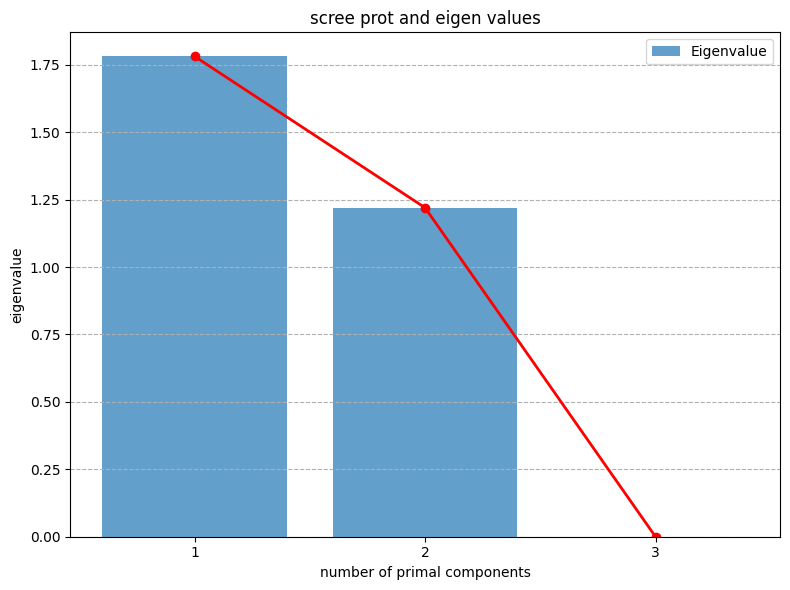


------
PC1: 0.5935 (59.35%)
PC2: 0.4065 (40.65%)
PC3: 0.0000 (0.00%)
enumarated variance (PC1+PC2): 1.0000


In [ ]:

# --- 前のステップで生成・回転したデータを使用 ---

# データを行列形式に結合 (N_samples, N_features)
data_matrix = np.column_stack((X, Y, Z))

# --- 手計算によるPCAステップ (相関係数行列を使用) ---

print("--- 手計算によるPCA (相関係数行列を使用) ---")

# 1. データの標準化 (Zスコア変換)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_matrix)

print("\n標準化されたデータの最初の5点:")
print(scaled_data[:5])

# 2. 相関係数行列の計算
# 標準化されたデータの共分散行列が相関係数行列に相当する
correlation_matrix_manual = np.cov(scaled_data, rowvar=False)
print("\n相関係数行列 (手計算):")
print(correlation_matrix_manual)

# 3. 固有値と固有ベクトルの計算
eigenvalues_manual, eigenvectors_manual = np.linalg.eig(correlation_matrix_manual)

# 固有値と固有ベクトルを対応する順序でソート (固有値の降順)
sorted_indices_manual = np.argsort(eigenvalues_manual)[::-1]
eigenvalues_sorted_manual = eigenvalues_manual[sorted_indices_manual]
eigenvectors_sorted_manual = eigenvectors_manual[:, sorted_indices_manual]

print("\nソートされた固有値 (手計算):")
print(eigenvalues_sorted_manual)

print("\nソートされた固有ベクトル (手計算 - 各列が主成分の方向):")
print(eigenvectors_sorted_manual)

# 4. 寄与度の計算
total_eigenvalue_manual = np.sum(eigenvalues_sorted_manual)
explained_variance_ratio_manual = eigenvalues_sorted_manual / total_eigenvalue_manual

print("\n寄与度 (手計算):")
for i, ratio in enumerate(explained_variance_ratio_manual):
    print(f"PC{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")

# 各軸のノーマルベクトル (ここでは各主成分の方向ベクトル)
print("\n各主成分の方向ベクトル (ノーマルベクトル - 手計算):")
print(f"PC1 (第1主成分): {eigenvectors_sorted_manual[:, 0]}")
print(f"PC2 (第2主成分): {eigenvectors_sorted_manual[:, 1]}")
print(f"PC3 (第3主成分): {eigenvectors_sorted_manual[:, 2]}")

# --- scikit-learnによるPCA (標準化込み) ---

print("\n\n--- scikit-learnによるPCA (標準化込み) ---")

# データの標準化とPCAをパイプラインで処理することも可能ですが、ここでは個別に実行します。
# 既にscalerで標準化されたデータを使用

pca = PCA(n_components=3)

# 標準化されたデータに対してPCAを実行
pca.fit(scaled_data)

# 固有値 (分散の大きさ)
print("\nscikit-learnの固有値 (explained_variance_):")
print(pca.explained_variance_)

# 寄与度 (説明された分散の割合)
print("\nscikit-learnの寄与度 (explained_variance_ratio_):")
print(pca.explained_variance_ratio_)
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")

# 固有ベクトル (主成分の方向)
print("\nscikit-learnの固有ベクトル (components_ - 各行が主成分の方向):")
print(pca.components_)

# --- 手計算とscikit-learnの結果比較 ---

print("\n--- 手計算とscikit-learnの結果比較 ---")
print("固有値 (Explained Variance) 比較:")
print(f"手計算: {eigenvalues_sorted_manual}")
print(f"scikit-learn: {pca.explained_variance_}")
print("寄与度 (Explained Variance Ratio) 比較:")
print(f"手計算: {explained_variance_ratio_manual}")
print(f"scikit-learn: {pca.explained_variance_ratio_}")
print("固有ベクトル (Components) 比較:")
print(f"手計算 (転置): \n{eigenvectors_sorted_manual.T}")
print(f"scikit-learn: \n{pca.components_}")
# 主成分スコア (変換されたデータ)
principal_components = pca.transform(scaled_data)

# 固有ベクトル (主成分の方向) - scikit-learnではcomponents_は転置されている
eigenvectors_pca = pca.components_
# 固有値 (主成分が説明する分散の量)
eigenvalues_pca = pca.explained_variance_
# 寄与度 (説明された分散の割合)
explained_variance_ratio_pca = pca.explained_variance_ratio_

# --- 1. スクリープロット (Scree Plot) ---
plt.figure(figsize=(8, 6))
plt.bar(range(1, len(eigenvalues_pca) + 1), eigenvalues_pca, alpha=0.7, align='center', label='Eigenvalue')
plt.plot(range(1, len(eigenvalues_pca) + 1), eigenvalues_pca, 'ro-', linewidth=2)
plt.title('scree prot and eigen values')
plt.xlabel('number of primal components')
plt.ylabel('eigenvalue')
plt.xticks(range(1, len(eigenvalues_pca) + 1))
plt.grid(axis='y', linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()



print("\n------")
for i, ratio in enumerate(explained_variance_ratio_pca):
    print(f"PC{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")
print(f"enumarated variance (PC1+PC2): {explained_variance_ratio_pca[0] + explained_variance_ratio_pca[1]:.4f}")


可視化

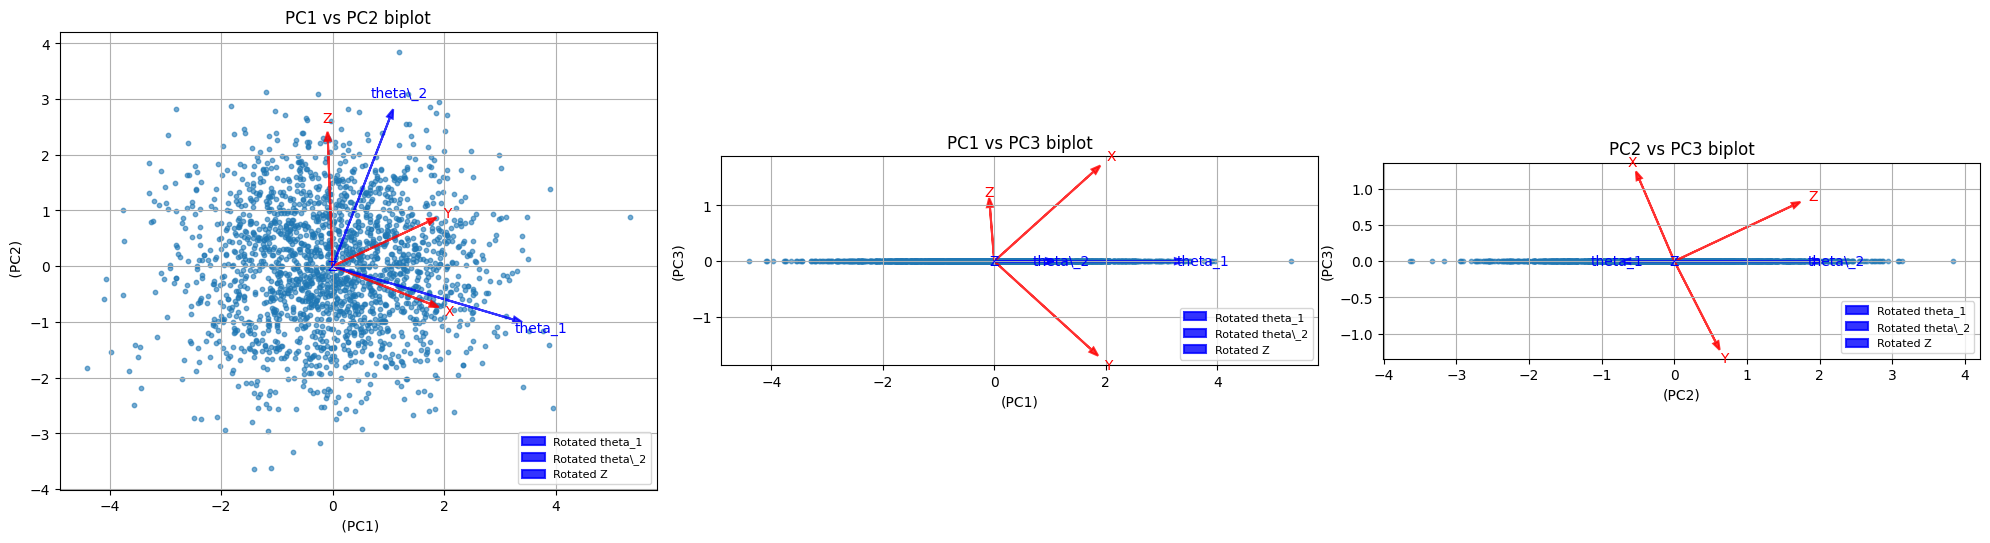

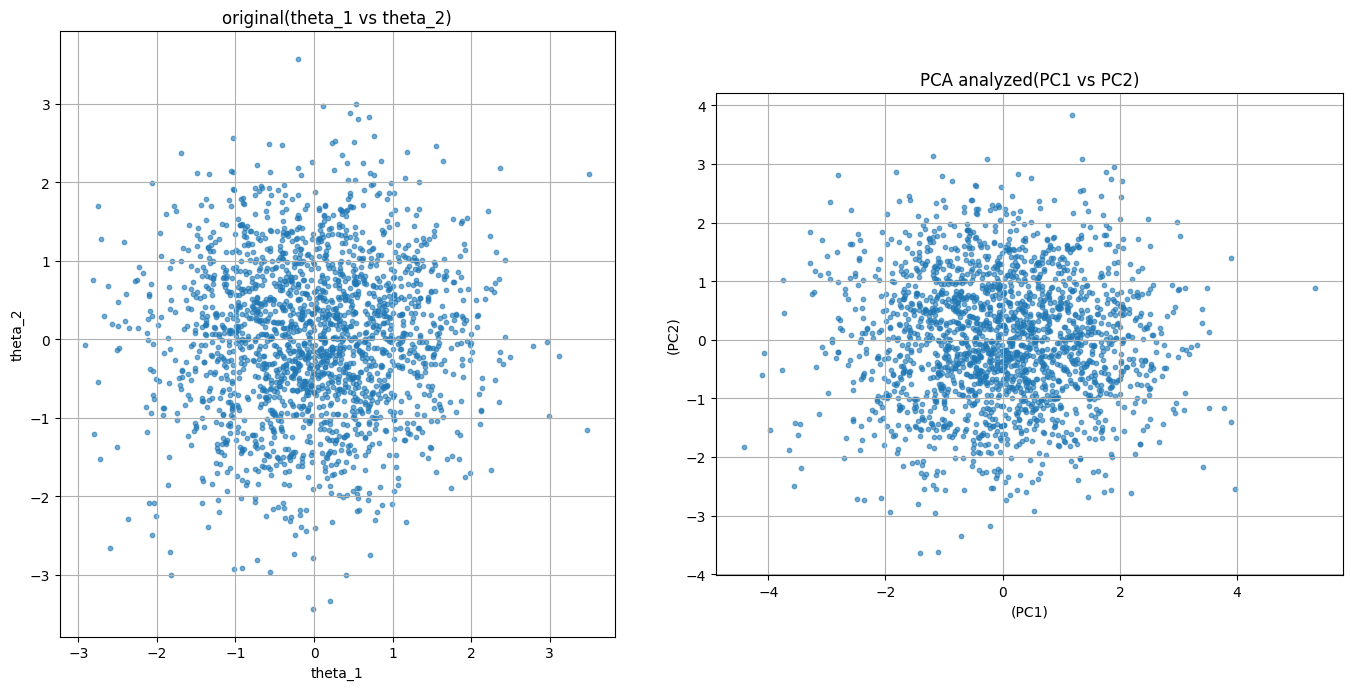

In [ ]:

# ---

### 2. バイプロット (Biplot) と $\theta_1, \theta_2$ ベクトルの追加

# 元の $\theta_1$ 軸と $\theta_2$ 軸の方向をPC空間に投影するには、それらが3次元空間でどのような方向を向いているかを把握する必要があります。

# 元の $\theta_1$ 軸は $(1, 0, 0)$ 方向、$\theta_2$ 軸は $(0, 1, 0)$ 方向として初期化され、その後に回転行列 $R$ が適用されました。したがって、これらの軸が回転後にどの方向を向いているかを計算できます。

# 回転後の軸の方向ベクトルは、元の軸の方向ベクトルに回転行列 $R$ をかけることで得られます。

# * 回転後の $\theta_1$ 方向: $R \cdot (1, 0, 0)^T$
# * 回転後の $\theta_2$ 方向: $R \cdot (0, 1, 0)^T$

# これらのベクトルを、PCA後の主成分空間に投影します。

# ```python
# --- 元のθ1, θ2軸が回転後にどの方向を向いているかを計算 ---
# 回転前の軸の方向ベクトル
theta1_axis_initial = np.array([1, 0, 0])
theta2_axis_initial = np.array([0, 1, 0])
theta3_axis_initial = np.array([0, 0, 0]) # 元のZ軸 (theta3) も考慮に入れる

# 回転行列Rを適用して、回転後の軸の方向ベクトルを取得
rotated_theta1_axis = R @ theta1_axis_initial
rotated_theta2_axis = R @ theta2_axis_initial
rotated_theta3_axis = R @ theta3_axis_initial

# これらの回転後の軸の方向ベクトルを標準化する
# 標準化はscaler.fit_transform(data_matrix)で行ったため、軸の方向も同様に変換する
# ただし、軸の方向ベクトルはデータのスケーリングとは異なる。
# PCAのcomponents_は標準化されたデータに対する変換なので、
# 元の軸の方向を標準化された空間に変換する必要がある。
# これは、各軸ベクトルを元のデータの標準偏差で割ることで実現できる。
# StandardScalerの内部では (x - mean) / std_dev と変換される。
# 方向ベクトルなのでmeanは0で、std_devで割るイメージ。

# データ全体の標準偏差で割ることで、PCA空間でのスケールに合わせる
# 各変数の標準偏差 (scaler.scale_ を使う)
std_devs_original_features = scaler.scale_

# 各回転後の軸の方向ベクトルを標準化された空間にマッピングする
# 注意: これは厳密な「ロード」ではないが、PC空間での方向を示すための近似
# 各成分を対応する特徴量の標準偏差で割る
scaled_rotated_theta1_axis = rotated_theta1_axis / std_devs_original_features
scaled_rotated_theta2_axis = rotated_theta2_axis / std_devs_original_features
scaled_rotated_theta3_axis = rotated_theta3_axis / std_devs_original_features # 元のZ軸も追加

# --- バイプロットのための関数 (θ1, θ2ベクトル追加) ---
def plot_biplot_with_original_axes(ax, pc_x, pc_y, title, x_label, y_label, eigenvalues, eigenvectors, feature_names,
                                   original_axis_vectors, original_axis_labels):
    # データ点のプロット
    ax.scatter(principal_components[:, pc_x], principal_components[:, pc_y], alpha=0.6, s=10)
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.grid(True)
    ax.set_aspect('equal', adjustable='box')

    # 元の変数の方向（ロード）をプロット
    # scikit-learnのcomponents_ は正規化されているので、矢印の長さを調整
    # 矢印の長さの調整係数 (PC空間での広がりを考慮)
    s_features = np.max(np.abs(principal_components[:, [pc_x, pc_y]])) / 2.0
    if s_features == 0: s_features = 1 # ゼロ除算対策

    for i, (comp_x, comp_y) in enumerate(zip(eigenvectors[pc_x], eigenvectors[pc_y])):
        ax.arrow(0, 0, comp_x * s_features, comp_y * s_features, color='red', alpha=0.8, lw=1.5,
                 head_width=0.04 * s_features, head_length=0.06 * s_features, length_includes_head=True)
        ax.text(comp_x * s_features * 1.1, comp_y * s_features * 1.1, feature_names[i], color='red', ha='center', va='center')

    # θ1, θ2, θ3(Z)ベクトルのプロット (回転後の軸の方向をPCA空間に投影)
    # PCA変換は principal_components = scaled_data @ eigenvectors_pca.T
    # したがって、元の軸の方向ベクトル (scaled_rotated_axis) をPCA空間に投影するには
    # そのベクトルを eigenvectors_pca.T との内積を取る
    for i, original_vec in enumerate(original_axis_vectors):
        # ベクトルをPCA空間に変換 (主成分軸への投影)
        projected_vec = original_vec @ eigenvectors_pca.T
        proj_x = projected_vec[pc_x]
        proj_y = projected_vec[pc_y]

        # 矢印の長さを調整 (PC空間でのデータの広がりを考慮)
        s_original_axes = np.max(np.abs(principal_components[:, [pc_x, pc_y]])) / 2.0
        if s_original_axes == 0: s_original_axes = 1 # ゼロ除算対策

        ax.arrow(0, 0, proj_x * s_original_axes, proj_y * s_original_axes, color='blue', alpha=0.8, lw=1.5,
                 head_width=0.04 * s_original_axes, head_length=0.06 * s_original_axes, length_includes_head=True,
                 label=f'Rotated {original_axis_labels[i]}')
        ax.text(proj_x * s_original_axes * 1.1, proj_y * s_original_axes * 1.1, original_axis_labels[i],
                color='blue', ha='center', va='center')
    ax.legend(loc='lower right', fontsize=8)


# 特徴量の名前 (X, Y, Z)
feature_names = ['X', 'Y', 'Z']
# 回転後のθ1, θ2, Z軸の名前
original_axis_labels = [r'theta_1', r'theta\_2', 'Z']
original_axis_vectors = [scaled_rotated_theta1_axis, scaled_rotated_theta2_axis, scaled_rotated_theta3_axis]


fig_biplot, axes_biplot = plt.subplots(1, 3, figsize=(20, 6))

# PC1 vs PC2
plot_biplot_with_original_axes(axes_biplot[0], 0, 1, 'PC1 vs PC2 biplot',
                               ' (PC1)', ' (PC2)', eigenvalues_pca, eigenvectors_pca,
                               feature_names, original_axis_vectors, original_axis_labels)

# PC1 vs PC3
plot_biplot_with_original_axes(axes_biplot[1], 0, 2, 'PC1 vs PC3 biplot',
                               '(PC1)', '(PC3)', eigenvalues_pca, eigenvectors_pca,
                               feature_names, original_axis_vectors, original_axis_labels)

# PC2 vs PC3
plot_biplot_with_original_axes(axes_biplot[2], 1, 2, 'PC2 vs PC3 biplot',
                               '(PC2)', '(PC3)', eigenvalues_pca, eigenvectors_pca,
                               feature_names, original_axis_vectors, original_axis_labels)

plt.tight_layout()
plt.show()

# ---

# ### 3. PC1, PC2 と <span class="math-inline">\\theta\_1, \\theta\_2</span> の散布図を左右に並べて比較

# ```python
fig_compare, axes_compare = plt.subplots(1, 2, figsize=(14, 7))

# 左側: θ1 vs θ2 (元の隠れたデータ)
axes_compare[0].scatter(theta1, theta2, alpha=0.6, s=10)
axes_compare[0].set_title(r'original(theta_1 vs theta_2)')
axes_compare[0].set_xlabel(r'theta_1')
axes_compare[0].set_ylabel(r'theta_2')
axes_compare[0].grid(True)
axes_compare[0].set_aspect('equal', adjustable='box')

# 右側: PC1 vs PC2 (PCA後のデータ)
axes_compare[1].scatter(principal_components[:, 0], principal_components[:, 1], alpha=0.6, s=10)
axes_compare[1].set_title('PCA analyzed(PC1 vs PC2)')
axes_compare[1].set_xlabel('(PC1)')
axes_compare[1].set_ylabel('(PC2)')
axes_compare[1].grid(True)
axes_compare[1].set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

In [ ]:
def logistic_function(theta, a, b):
    """2-parameter logistic function."""
    # Ensure theta is treated as a numpy array for element-wise operations
    theta = np.asarray(theta)
    return 1 / (1 + np.exp(-a * (theta - b)))

def logistic_function_central_item(distance, a_val, b_val):
    """
    中心型項目に対する正答確率を計算（能力が中心から離れるほど確率が下がる）。
    distance: ユーザーの中心からの距離
    a_val: 識別力（正の値、カーブの急峻さ）
    b_val: 中心からの距離がこの値の時に確率が50%になる閾値
    """
    # 距離がb_valより小さいほど確率が高くなるようにする
    return 1 / (1 + np.exp(a_val * (distance - b_val)))

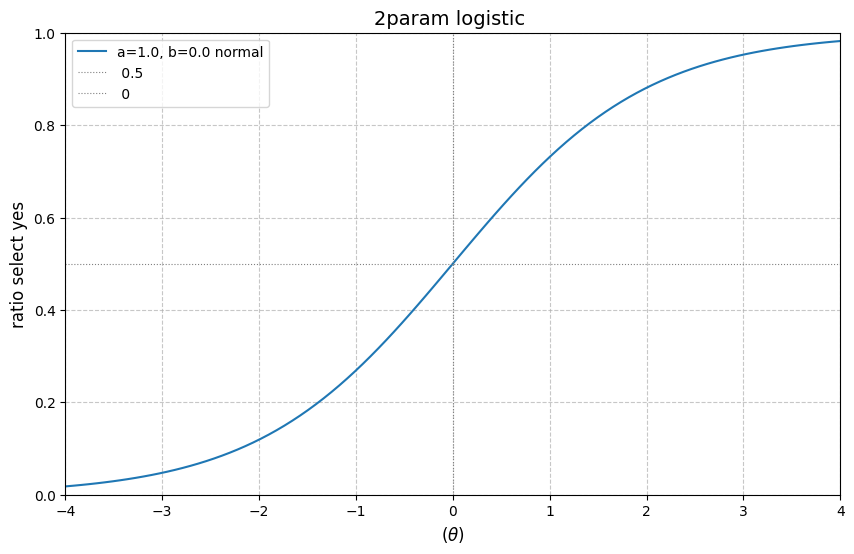

In [ ]:
theta_values = np.linspace(-4, 4, 100) # -4から4まで100点

# パラメータ a と b の設定
# 異なる曲線を比較するために複数のパターンを定義
parameters = [
    {'a': 1.0, 'b': 0.0, 'label': 'a=1.0, b=0.0 normal'},

]

# --- プロットの作成 ---
plt.figure(figsize=(10, 6))

for params in parameters:
    a_val = params['a']
    b_val = params['b']
    label_val = params['label']

    # ロジスティック関数を適用して正答率を計算
    probability_correct = logistic_function(theta_values, a_val, b_val)

    # プロット
    plt.plot(theta_values, probability_correct, label=label_val)

# --- グラフの装飾 ---
plt.title('2param logistic ', fontsize=14)
plt.xlabel('($\\theta$)', fontsize=12)
plt.ylabel('ratio select yes', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0.5, color='gray', linestyle=':', linewidth=0.8, label=' 0.5')
plt.axvline(0, color='gray', linestyle=':', linewidth=0.8, label=' 0')
plt.legend(fontsize=10)
plt.ylim(0, 1) # 縦軸（正答率）の範囲を0から1に固定
plt.xlim(theta_values.min(), theta_values.max()) # 横軸の範囲を固定
plt.show()

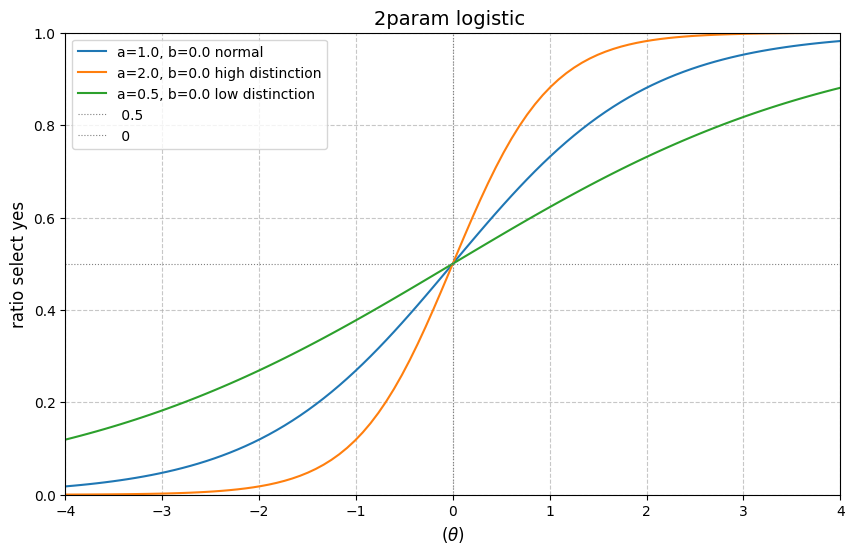

In [ ]:
theta_values = np.linspace(-4, 4, 100) # -4から4まで100点

# パラメータ a と b の設定
# 異なる曲線を比較するために複数のパターンを定義
parameters = [
    {'a': 1.0, 'b': 0.0, 'label': 'a=1.0, b=0.0 normal'},
    {'a': 2.0, 'b': 0.0, 'label': 'a=2.0, b=0.0 high distinction'},
    {'a': 0.5, 'b': 0.0, 'label': 'a=0.5, b=0.0 low distinction'},

]

# --- プロットの作成 ---
plt.figure(figsize=(10, 6))

for params in parameters:
    a_val = params['a']
    b_val = params['b']
    label_val = params['label']

    # ロジスティック関数を適用して正答率を計算
    probability_correct = logistic_function(theta_values, a_val, b_val)

    # プロット
    plt.plot(theta_values, probability_correct, label=label_val)

# --- グラフの装飾 ---
plt.title('2param logistic ', fontsize=14)
plt.xlabel('($\\theta$)', fontsize=12)
plt.ylabel('ratio select yes', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0.5, color='gray', linestyle=':', linewidth=0.8, label=' 0.5')
plt.axvline(0, color='gray', linestyle=':', linewidth=0.8, label=' 0')
plt.legend(fontsize=10)
plt.ylim(0, 1) # 縦軸（正答率）の範囲を0から1に固定
plt.xlim(theta_values.min(), theta_values.max()) # 横軸の範囲を固定
plt.show()

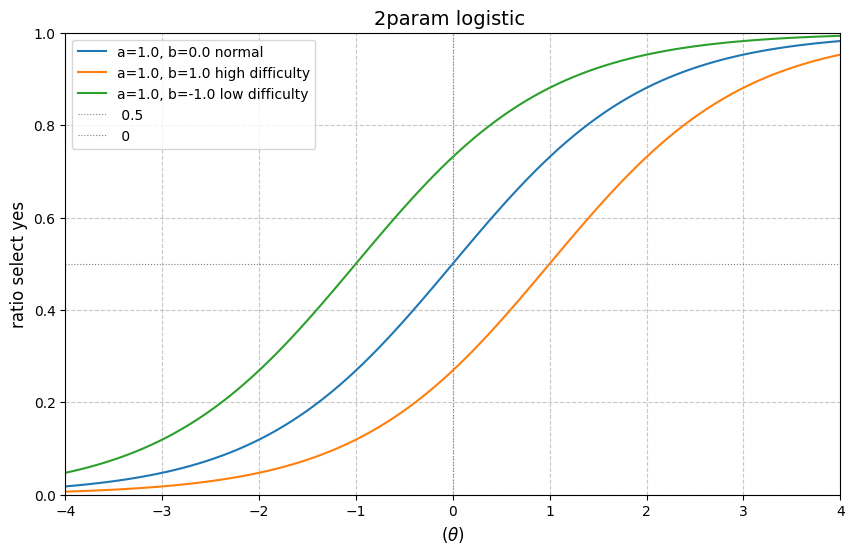

In [ ]:
theta_values = np.linspace(-4, 4, 100) # -4から4まで100点

# パラメータ a と b の設定
# 異なる曲線を比較するために複数のパターンを定義
parameters = [
    {'a': 1.0, 'b': 0.0, 'label': 'a=1.0, b=0.0 normal'},
    {'a': 1.0, 'b': 1.0, 'label': 'a=1.0, b=1.0 high difficulty'},
    {'a': 1.0, 'b': -1.0, 'label': 'a=1.0, b=-1.0 low difficulty'},
]

# --- プロットの作成 ---
plt.figure(figsize=(10, 6))

for params in parameters:
    a_val = params['a']
    b_val = params['b']
    label_val = params['label']

    # ロジスティック関数を適用して正答率を計算
    probability_correct = logistic_function(theta_values, a_val, b_val)

    # プロット
    plt.plot(theta_values, probability_correct, label=label_val)

# --- グラフの装飾 ---
plt.title('2param logistic ', fontsize=14)
plt.xlabel('($\\theta$)', fontsize=12)
plt.ylabel('ratio select yes', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0.5, color='gray', linestyle=':', linewidth=0.8, label=' 0.5')
plt.axvline(0, color='gray', linestyle=':', linewidth=0.8, label=' 0')
plt.legend(fontsize=10)
plt.ylim(0, 1) # 縦軸（正答率）の範囲を0から1に固定
plt.xlim(theta_values.min(), theta_values.max()) # 横軸の範囲を固定
plt.show()